# Linear Regression in Practice: Diagnostics, Feature Engineering, Transformations, and Reproducible Pipelines

This notebook is designed to build the **core skills** required to use linear regression responsibly in real projects. Instead of treating modeling as a one-step fit, we focus on a full workflow: understanding assumptions, preparing features, preventing data leakage, and evaluating model performance with clear interpretation.

By the end of this notebook, you should be able to connect statistical concepts to implementation decisions in scikit-learn and justify each preprocessing/modeling step in both academic and industry settings.

## Skills You Will Build

- Diagnose key linear regression assumptions using visual and statistical checks.
- Handle skewed targets with transformations and interpret when transformations help.
- Engineer and encode features for mixed-type tabular data.
- Apply train/test split and scaling correctly to avoid data leakage.
- Train, evaluate, and compare linear regression models using MSE and $R^2$.
- Build end-to-end, reproducible workflows using pipelines.

## Workflow Roadmap

0. Setup
1. Data Cleaning and Wrangling
2. Exploratory Data Analysis (EDA)
3. Testing Assumptions for Linear Regression
4. Linear Regression Modeling Workflow
5. Train-Test Split
6. Standardize Features
7. Linear Regression Model Training
8. Generate Predictions
9. Model Evaluation
10. Pipeline Object

***


## Step 0: Setup

Before modeling, we establish a reproducible environment and verify core library versions. This reduces debugging overhead later and ensures that preprocessing and model behavior are consistent across runs.

### 0.1. Import Required Libraries

The next code cells import modeling, plotting, and statistics utilities used throughout the notebook. Keep imports centralized so downstream cells are easier to audit and maintain.

In [2]:
# All Libraries required for this lab are listed below. Uncomment the lines to install the libraries if you are running this notebook in your local environment for the first time.
#%pip install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# You can update scikit-learn to the latest version using the command below.
#%pip install -U scikit-learn

In [3]:
import sklearn; 
print("Scikit-Learn", sklearn.__version__)

Scikit-Learn 1.7.2


In [4]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pylab as plt
%matplotlib inline

from scipy.stats import boxcox
from scipy.stats.mstats import normaltest

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.pipeline import Pipeline

# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

### 0.2. Reading and Understanding the Data

We begin with data inspection before feature engineering or model fitting. This step helps prevent silent issues (incorrect types, missing values, duplicates, inconsistent labels) that can degrade model quality.

For this guide, we use the Car Price dataset from [Kaggle](https://www.kaggle.com/datasets/goyalshalini93/car-data). You can also download the dataset (`CarPrice_Assignment.csv` file) from the [data](https://github.com/Souvik-Mandal-Harvard/Machine-Learning-for-Data-Science/tree/264cbe72ee2ba77750aeac03abe3d47ad6126df8/supervised-ML/data) folder of this repo.

The dataset contains car characteristics (categorical and numeric) and a target variable, `price`. Our goal is to model price while preserving interpretability and sound evaluation practice.

Load the dataset into a pandas DataFrame and inspect the first rows with `head()`.

Pay attention to the column names, basic value formats, and whether the target variable appears as expected before deeper diagnostics.

In [5]:
data = pd.read_csv('data/CarPrice_Assignment.csv')
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


Use `info()` to verify data types, non-null counts, and memory footprint.

This is the fastest way to identify schema issues that will affect preprocessing (for example, object columns that require encoding).

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

From `info()` we can confirm row count, feature count, and data-type mix. The target variable is `price`; all other columns are candidate predictors.

The next step uses `describe()` to summarize central tendency, spread, and range for numeric features. This helps detect scale disparities and extreme values before modeling.

In [7]:
data.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## 1. Data Cleaning and Wrangling

In this section, we check data integrity, resolve naming inconsistencies, and create modeling-ready features. Clean input data is a prerequisite for trustworthy inference and stable prediction performance.

Remember the phrase “**Garbage in, garbage out**”: a foundational principle in computer science and data analytics stating that model quality depends strongly on data quality. If the input data contain errors, inconsistencies, missing values, or poorly defined features, even a well-chosen model can produce unreliable results.

#### 1.1. First, check missing values across columns.

Missingness can bias model coefficients and impact encoding/scaling steps if not handled explicitly.

In [8]:
data.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

#### 1.2. Next, check duplicates in  unique entry column

In this dataset, `car_ID` should uniquely identify each record. Duplicate records can leak repeated information into train/test splits and distort both fit quality and evaluation metrics.

In [9]:
sum(data.duplicated(subset = 'car_ID')) == 0

True

#### 1.3. Inspect raw values of `CarName`
This will let us understand how manufacturer and model are encoded. This informs the feature engineering step that follows.

In [10]:
print(data["CarName"].unique())

['alfa-romero giulia' 'alfa-romero stelvio' 'alfa-romero Quadrifoglio'
 'audi 100 ls' 'audi 100ls' 'audi fox' 'audi 5000' 'audi 4000'
 'audi 5000s (diesel)' 'bmw 320i' 'bmw x1' 'bmw x3' 'bmw z4' 'bmw x4'
 'bmw x5' 'chevrolet impala' 'chevrolet monte carlo' 'chevrolet vega 2300'
 'dodge rampage' 'dodge challenger se' 'dodge d200' 'dodge monaco (sw)'
 'dodge colt hardtop' 'dodge colt (sw)' 'dodge coronet custom'
 'dodge dart custom' 'dodge coronet custom (sw)' 'honda civic'
 'honda civic cvcc' 'honda accord cvcc' 'honda accord lx'
 'honda civic 1500 gl' 'honda accord' 'honda civic 1300' 'honda prelude'
 'honda civic (auto)' 'isuzu MU-X' 'isuzu D-Max ' 'isuzu D-Max V-Cross'
 'jaguar xj' 'jaguar xf' 'jaguar xk' 'maxda rx3' 'maxda glc deluxe'
 'mazda rx2 coupe' 'mazda rx-4' 'mazda glc deluxe' 'mazda 626' 'mazda glc'
 'mazda rx-7 gs' 'mazda glc 4' 'mazda glc custom l' 'mazda glc custom'
 'buick electra 225 custom' 'buick century luxus (sw)' 'buick century'
 'buick skyhawk' 'buick opel isuzu 

### 1.4. Extract and Standardize the Brand from `CarName`

`CarName` combines two different pieces of information: the manufacturer (`brand`) and the specific car `model`. If we keep the full string as a single raw category, we make it harder to distinguish whether price differences are associated with manufacturer-level effects or with model-specific differences.

In this guide, we separate out the `brand` because it can reasonably contribute to price, and it is easier to use as a structured categorical feature in the workflow that follows. For simplicity, we do **not** retain the model name as a separate feature here; instead, we drop the remaining raw `CarName` field later in the guide.

Enthusiastic learners may choose to retain and engineer the model name as an additional feature, but that would require extra cleaning and careful handling because model labels are often sparse, inconsistent, and highly granular.

In [11]:
data['brand'] = data.CarName.str.split(' ').str.get(0).str.lower()

Review the distinct brand labels after extraction.

This gives a quick sanity check before correcting known misspellings and aliases.

In [12]:
data.brand.unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

Some manufacturer names contain typos or inconsistent spellings. We standardize these labels now.

Without normalization, equivalent brands would be treated as different categories during encoding, weakening model signal.

In [13]:
data['brand'] = data['brand'].replace(['vw', 'vokswagen'], 'volkswagen')
data['brand'] = data['brand'].replace(['maxda'], 'mazda')
data['brand'] = data['brand'].replace(['porcshce'], 'porsche')
data['brand'] = data['brand'].replace(['toyouta'], 'toyota')

In [14]:
data.brand.unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

Plot the frequency of each brand to understand class balance in categorical data.

This can reveal sparse categories that may require careful interpretation later.

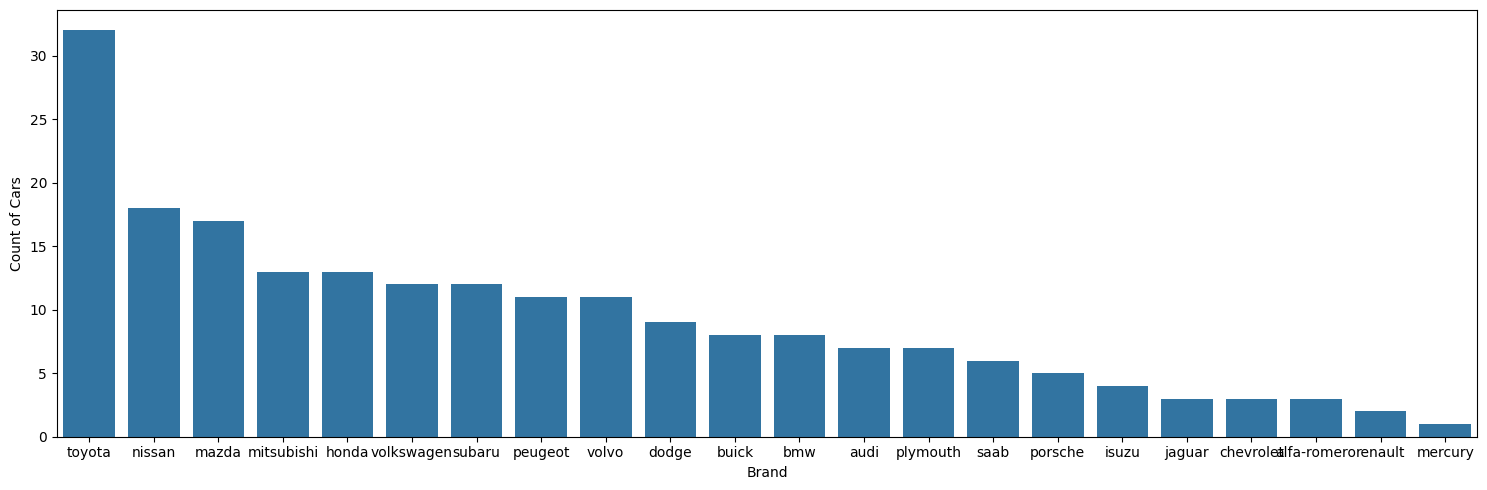

In [15]:
fig, ax = plt.subplots(figsize = (15,5))
plt1 = sns.countplot(x='brand', data=data, order=data['brand'].value_counts().index)
plt1.set(xlabel = 'Brand', ylabel= 'Count of Cars')
plt.tight_layout()
plt.show()

Drop columns not needed for modeling: identifiers and redundant raw text fields.

Rationale: `car_ID` is an identifier, `symboling` is excluded in this workflow, and `CarName` has already been decomposed into `brand`.

In [16]:
data.drop(['car_ID', 'symboling', 'CarName'],axis = 1, inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fueltype          205 non-null    object 
 1   aspiration        205 non-null    object 
 2   doornumber        205 non-null    object 
 3   carbody           205 non-null    object 
 4   drivewheel        205 non-null    object 
 5   enginelocation    205 non-null    object 
 6   wheelbase         205 non-null    float64
 7   carlength         205 non-null    float64
 8   carwidth          205 non-null    float64
 9   carheight         205 non-null    float64
 10  curbweight        205 non-null    int64  
 11  enginetype        205 non-null    object 
 12  cylindernumber    205 non-null    object 
 13  enginesize        205 non-null    int64  
 14  fuelsystem        205 non-null    object 
 15  boreratio         205 non-null    float64
 16  stroke            205 non-null    float64
 1

In [17]:
#If you want to save this partially processed data, uncomment the line below.
#data.to_csv('cleaned_car_data.csv', index=False)

### 1.5. Exercise 1

Explore object-type variables of your choice and summarize what they imply for encoding or feature design.

For example,
- Which are the categories in some columns?
- Which categories are dominant or rare?
- Are there possible spelling inconsistencies?

In [18]:
# If you want to see the unique 'fueltype'.
print(data.fueltype.unique())
print("-" * 10)

# Similarly, if you want to see the count of unique values in the 'enginelocation' column
print(data["enginelocation"].value_counts())

['gas' 'diesel']
----------
enginelocation
front    202
rear       3
Name: count, dtype: int64


### 1.6. Create a Brand-Level Price Category Feature

At this point, we have a cleaned `brand` column. Now we will engineer one more feature: `brand_category`.

Why this can help understand the model better:

- Some brands are generally associated with lower-priced cars, while others are associated with higher-priced cars.
- Grouping brands into broad pricing tiers gives us an interpretable market-segment feature.
- This feature does **not** replace detailed variables like engine size or horsepower; it complements them.

What we will do in the next code cells:
1. Compute the average `price` for each `brand`.
2. Merge that brand-level average back into the main table.
3. Convert average brand price into three categories: `Budget`, `Mid_Range`, and `Luxury`.

In [19]:
# Step 1: Compute average price for each brand.
data_comp_avg_price = (
    data[['brand', 'price']]
    .groupby('brand', as_index=False)
    .mean()
    .rename(columns={'price': 'brand_avg_price'})
)

# Step 2: Attach the brand-level average price back to each car row.
data = data.merge(data_comp_avg_price, on='brand')

In [20]:
data.head()

,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand,brand_avg_price
0,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,...,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,15498.333333
1,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,...,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,15498.333333
2,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,...,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,15498.333333
3,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,...,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,17859.166714
4,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,...,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,17859.166714


Before assigning categories, quickly inspect the distribution of `brand_avg_price`.

This helps us choose thresholds that are easy to explain and reasonably aligned with the dataset scale.

In this guide, we use simple instructional cutoffs:

- `Budget`: average brand price < 10,000
- `Mid_Range`: 10,000 to < 20,000
- `Luxury`: 20,000 and above

In [21]:
# Quick summary to sanity-check the scale before binning.
data.brand_avg_price.describe()

count      205.000000
mean     13276.710571
std       7154.179185
min       6007.000000
25%       9239.769231
50%      10077.500000
75%      15489.090909
max      34600.000000
Name: brand_avg_price, dtype: float64

In [22]:
# Step 3: Convert average brand price into broad market-segment labels.
data['brand_category'] = data['brand_avg_price'].apply(
    lambda x: 'Budget' if x < 10000
    else ('Mid_Range' if 10000 <= x < 20000 else 'Luxury')
)

## 2. Exploratory Data Analysis (EDA)

Now that the data is cleaned and key features are prepared, we move to exploration. The goal here is to build intuition before modeling:

- Which categorical groups tend to have higher or lower prices?
- Which numeric features move together with price?
- Are there early signs of relationships that may help or hurt linear regression?

### 2.0. Categorical Variables to Examine

We start by comparing price distributions across these categorical variables:

- `brand_category`
- `fueltype`
- `enginetype`
- `carbody`
- `doornumber`
- `enginelocation`
- `fuelsystem`
- `cylindernumber`
- `aspiration`
- `drivewheel`

To capture both center and spread of each group, we will use **violin plots**.

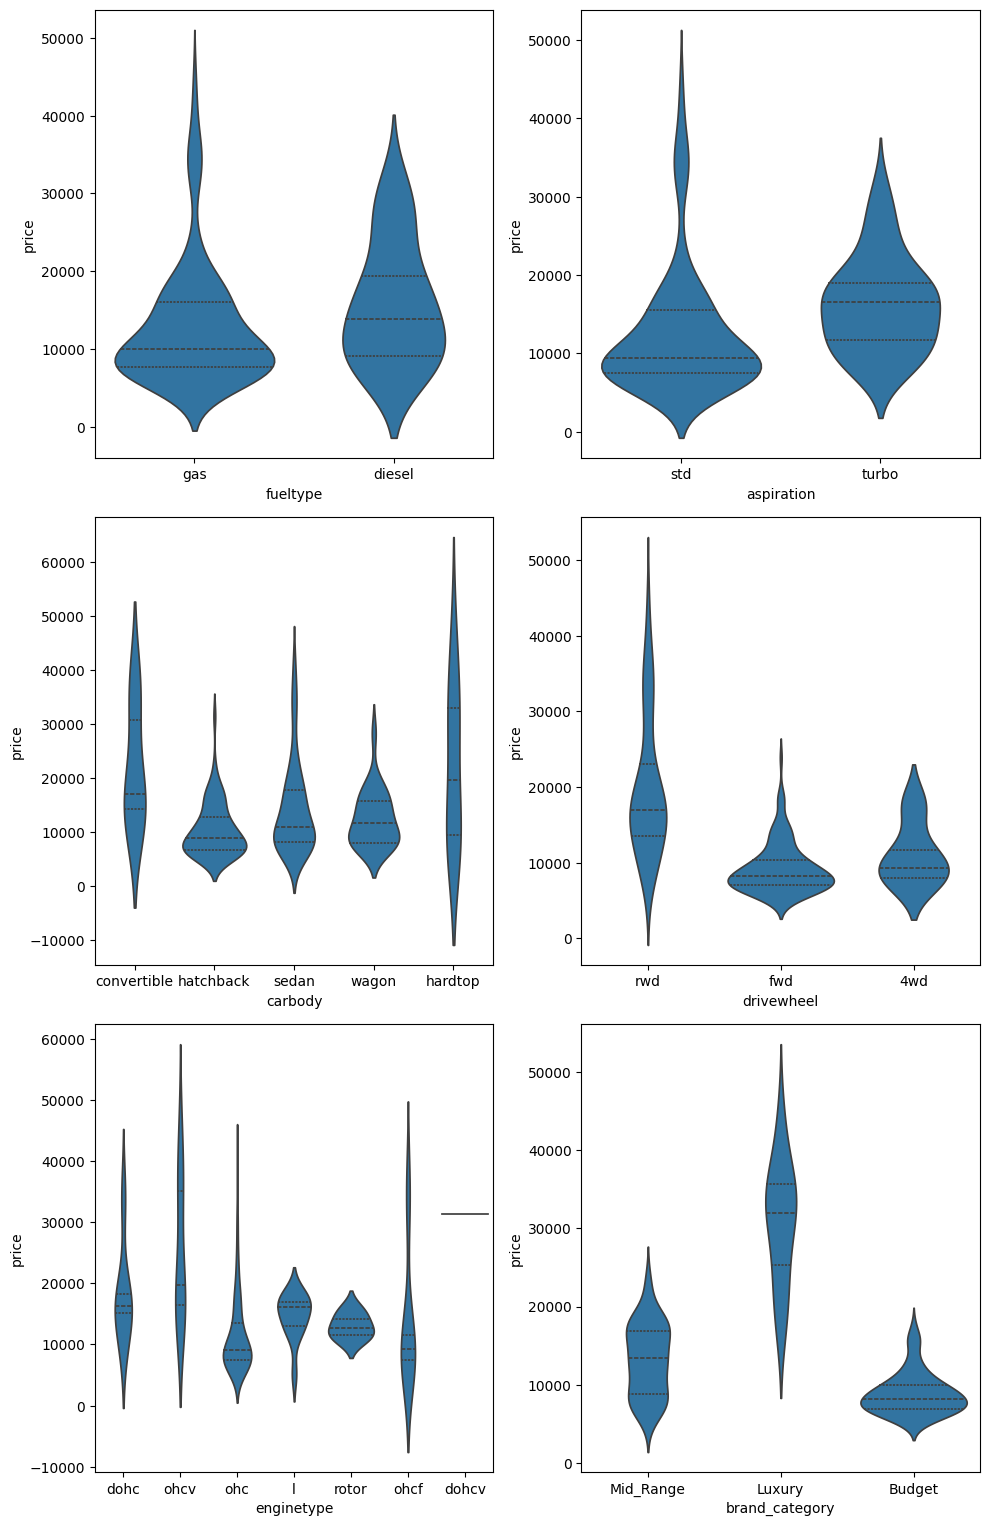

In [23]:
# Compare how price is distributed across key categorical features using violin plots.
plt.figure(figsize=(10, 20))

plt.subplot(4, 2, 1)
sns.violinplot(x='fueltype', y='price', data=data, inner='quartile')

plt.subplot(4, 2, 2)
sns.violinplot(x='aspiration', y='price', data=data, inner='quartile')

plt.subplot(4, 2, 3)
sns.violinplot(x='carbody', y='price', data=data, inner='quartile')

plt.subplot(4, 2, 4)
sns.violinplot(x='drivewheel', y='price', data=data, inner='quartile')

plt.subplot(4, 2, 5)
sns.violinplot(x='enginetype', y='price', data=data, inner='quartile')

plt.subplot(4, 2, 6)
sns.violinplot(x='brand_category', y='price', data=data, inner='quartile')

plt.tight_layout()
plt.show()

### 2.1. Explore Linear Relationships in Numeric Features

Next, we check how strongly numeric features are linearly associated with `price`.

This inspection is important because linear regression learns linear patterns, and this gives an early signal of which variables may be useful predictors.

In [24]:
# Compute correlation among numeric columns only.
corr_matrix = data.corr(numeric_only=True)

# Show correlations with price, sorted from strongest positive to weakest.
corr_matrix['price'].sort_values(ascending=False)

price               1.000000
brand_avg_price     0.895520
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
peakrpm            -0.085267
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64

This ranking helps us quickly spot candidate predictors, but data scientists use it as an initial guide only.

> Important reminder: correlation is pairwise and linear. It does **not** capture interactions, nonlinear effects, or causal relationships.

To deepen intuition, we can use visual diagnostics in addition to a correlation table:

- A heatmap gives a compact view of many pairwise linear relationships.
- A pairplot helps reveal shape, spread, and possible nonlinearity in feature relationships.

### 2.2. Exercise 2

Use `pairplot()` to visually inspect relationships among selected features and `price`.

Try to identify:

- one feature that looks roughly linear with price
- one feature that looks weakly related or nonlinear

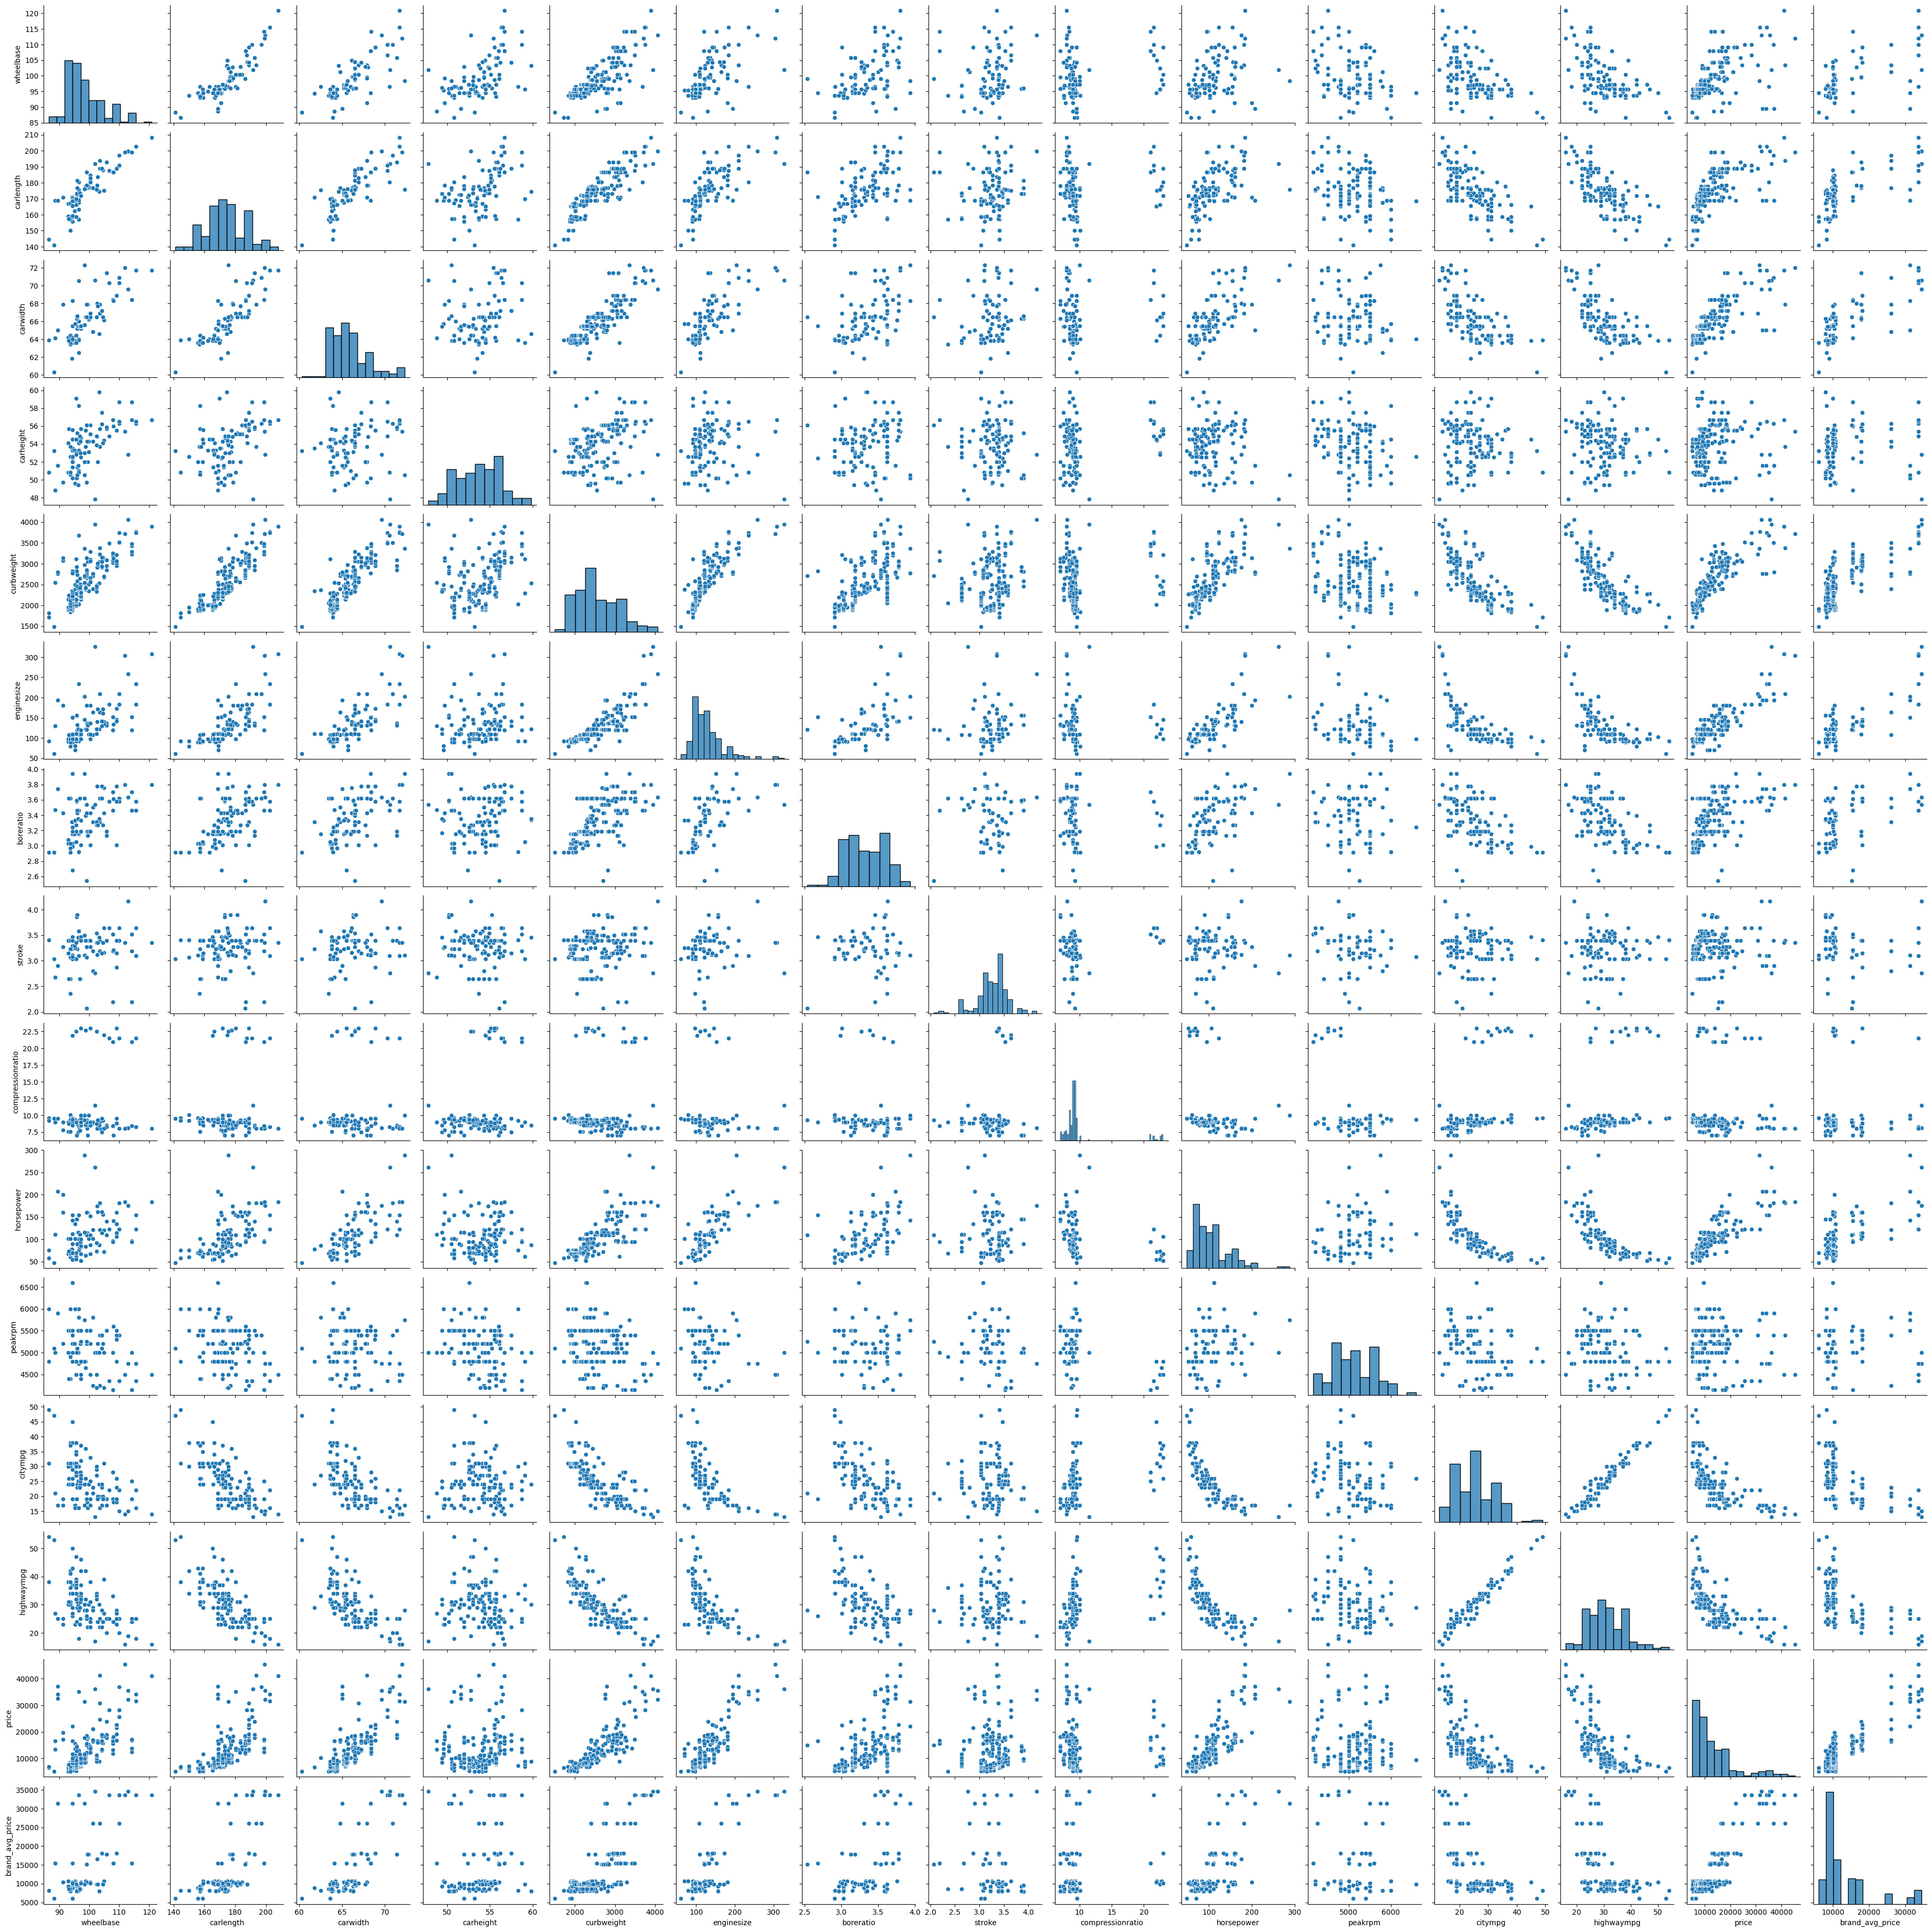

In [25]:
# Exercise: visualize pairwise relationships and distributions.
sns.pairplot(data)
plt.show()

## 3. Testing Assumptions for Linear Regression

Before we fit a linear model, we need to check whether core assumptions are reasonably satisfied. These checks do not need to be perfect, but they help us decide whether transformations or alternative modeling choices are needed.

In this section, we inspect four practical assumptions:

1. Linearity between predictors and target
2. Constant error variance (homoscedasticity)
3. Normality-related behavior of the target/residual pattern
4. Multicollinearity among predictors

> **Why is `price` always on the y-axis in these plots?**

> Because `price` is our target (dependent variable). In regression, we model how predictors (x-axis) explain variation in the target (y-axis). Keeping `price` on y-axis lets us consistently answer the same question: *how does this feature relate to the target we want to predict?*

### 3.1. Linearity Assumption

A linear regression model assumes that the expected value of `price` changes approximately linearly with each predictor.

Below, we start with `enginesize` and `horsepower`:

- x-axis: predictor
- y-axis: `price` (target)

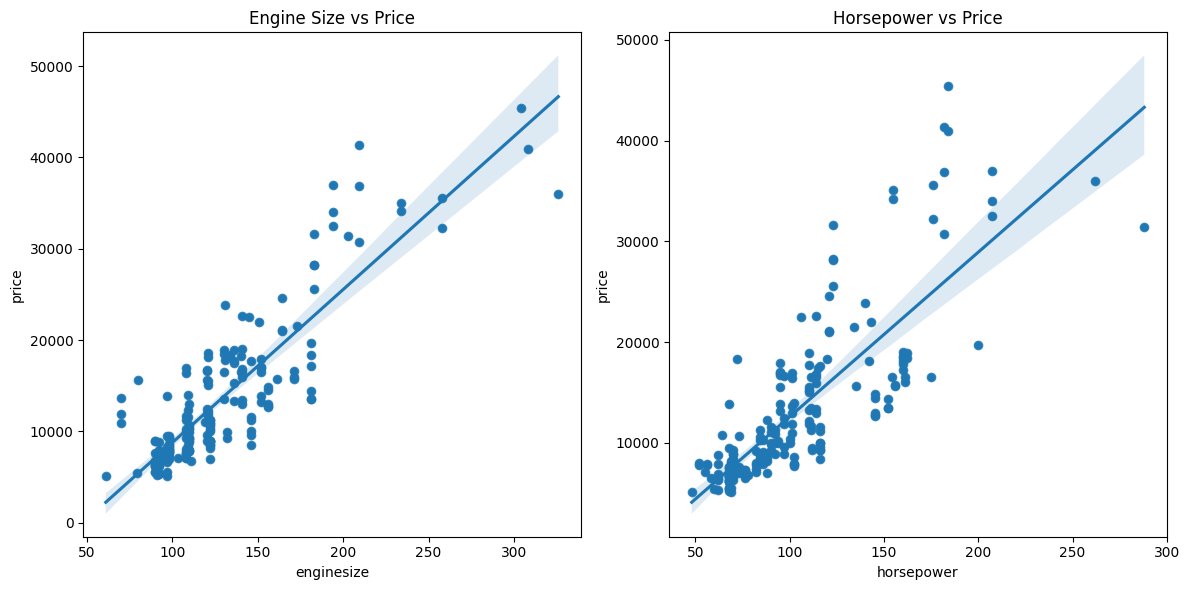

In [26]:
# Side-by-side linearity checks for two predictors against the same target (price).
fig, (ax1, ax2) = plt.subplots(figsize=(12, 6), ncols=2, sharey=False)

# Predictor on x-axis, target (price) on y-axis.
sns.scatterplot(x=data.enginesize, y=data.price, ax=ax1)
sns.regplot(x=data.enginesize, y=data.price, ax=ax1)
ax1.set_title('Engine Size vs Price')

sns.scatterplot(x=data.horsepower, y=data.price, ax=ax2)
sns.regplot(x=data.horsepower, y=data.price, ax=ax2)
ax2.set_title('Horsepower vs Price')

plt.tight_layout()

#### 3.1.1. Exercise 3

Pick another numeric predictor and plot it against `price` using `regplot()`.

Keep the same orientation (predictor on x, `price` on y) so your comparison remains consistent with earlier plots.

Interpretation prompts:

- Does the relationship look roughly linear across the full range?
- Is the relationship strong, weak, or possibly nonlinear?

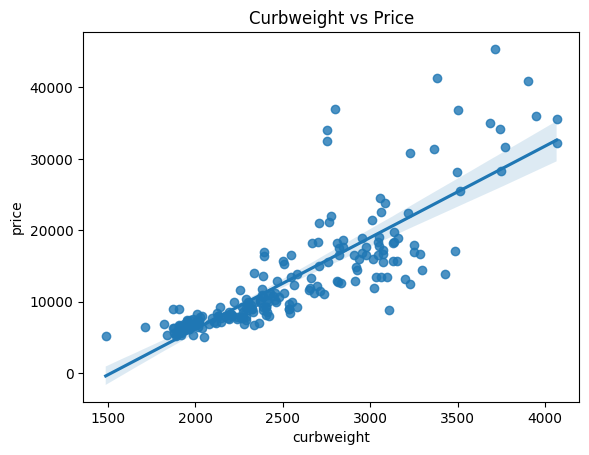

In [27]:
# Example solution: predictor on x-axis, target (price) on y-axis.
sns.regplot(x=data.curbweight, y=data.price, data=data)
plt.title('Curbweight vs Price')
plt.show()

### 3.2. Homoscedasticity (Constant Error Variance)

Homoscedasticity means the spread of prediction errors stays roughly similar across the range of a predictor.

Linear regression can still fit a line when this assumption is violated, but uncertainty estimates and confidence intervals become less trustworthy.

If variance increases or decreases systematically (a funnel pattern), coefficient estimates remain unbiased under some conditions, but uncertainty estimates and prediction intervals become less reliable.

In the next plot, we again keep `price` as the target on the y-axis and inspect residual behavior against `enginesize`.

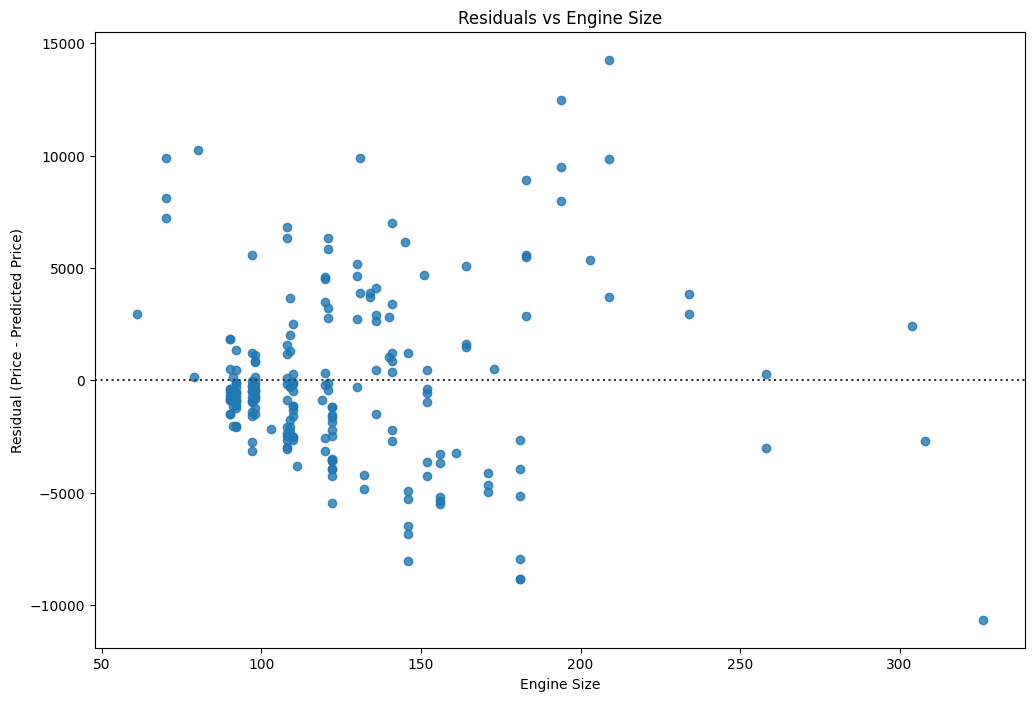

In [28]:
# Residual plot to check whether error spread stays roughly constant.
plt.figure(figsize=(12, 8))
sns.residplot(x=data.enginesize, y=data.price)
plt.title('Residuals vs Engine Size')
plt.xlabel('Engine Size')
plt.ylabel('Residual (Price - Predicted Price)')
plt.show()

How to read this plot:

- If the residual cloud has a fairly uniform vertical spread, homoscedasticity is more plausible.
- If it widens or narrows systematically (funnel shape), that suggests heteroscedasticity.

When heteroscedasticity is present, we often consider transformations or alternative modeling strategies to improve reliability.

This motivates transformation and feature engineering steps introduced below.

### 3.3. Normality of Target/Residual Behavior

Linear regression does not require predictors to be normally distributed, but strong skew in the target can still make model behavior harder to interpret.

In this step, we examine the target variable `price` using three complementary views:

- **Histogram**: shows the overall shape (symmetric vs skewed).

- **Q-Q plot (Quantile-Quantile plot)**: compares your observed quantiles to the quantiles of a perfect normal distribution. If points lie close to a straight reference line, normality is more plausible. Systematic curves or large tail deviations indicate non-normality. For a short and nice YouTube tutorial, watch this from [StatQuest with Josh Starmer](https://www.youtube.com/watch?v=okjYjClSjOg&t=232s).

- **Violin plot**: summarizes spread, density, and potential outliers in one compact view.

Together, these plots help us decide whether a transformation (such as log or Box-Cox) may improve modeling stability.

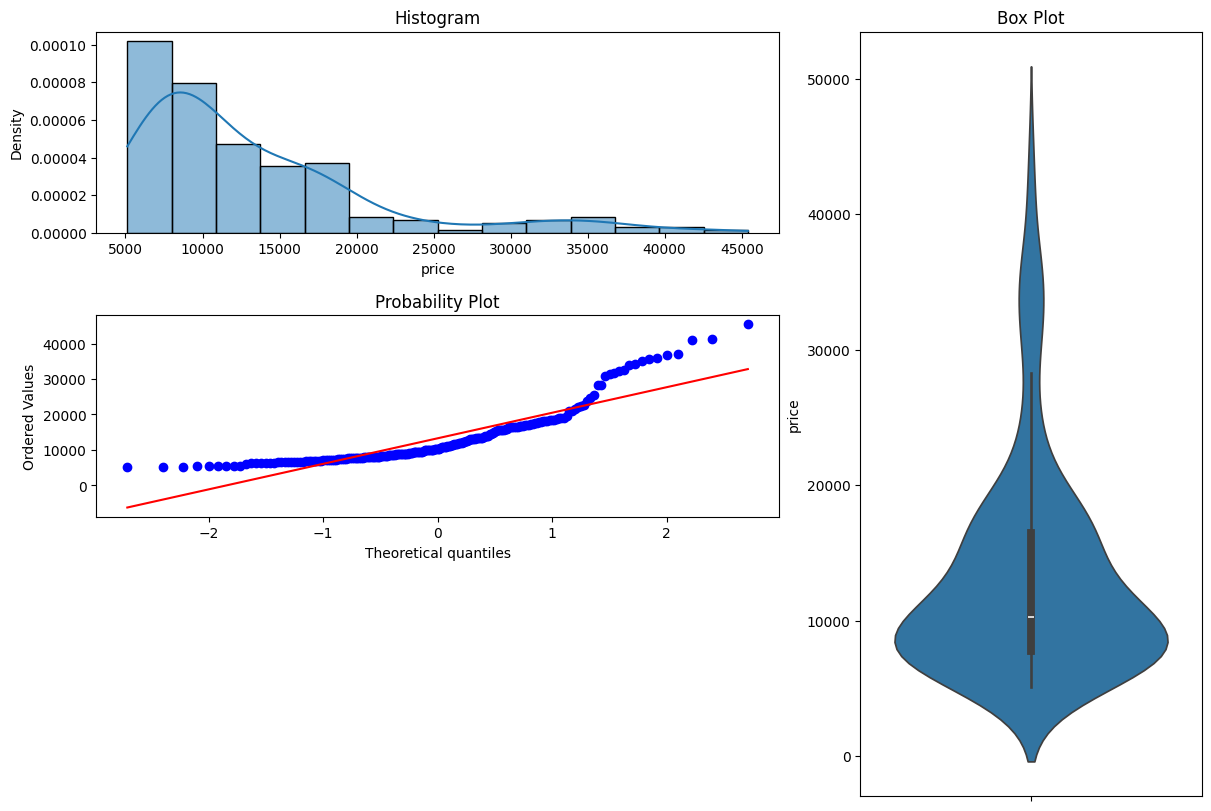

In [29]:
def plotting_3_chart(data, feature):
    import matplotlib.gridspec as gridspec
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats

    # Build a 3-panel diagnostic figure: histogram, Q-Q plot, and box plot.
    fig = plt.figure(constrained_layout=True, figsize=(12, 8))
    grid = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)

    # 1) Histogram + KDE: quick view of skew and modality.
    ax1 = fig.add_subplot(grid[0, :2])
    ax1.set_title('Histogram')
    sns.histplot(data.loc[:, feature], kde=True, stat='density', ax=ax1)

    # 2) Q-Q plot: compare sample quantiles to theoretical normal quantiles.
    ax2 = fig.add_subplot(grid[1, :2])
    ax2.set_title('Q-Q Plot')
    stats.probplot(data.loc[:, feature], plot=ax2)

    # 3) Box plot: compact view of spread and potential outliers.
    ax3 = fig.add_subplot(grid[:, 2])
    ax3.set_title('Box Plot')
    sns.violinplot(y=data.loc[:, feature], ax=ax3)

plotting_3_chart(data, 'price')

From these diagnostics, `price` appears right-skewed rather than approximately normal.

Why this matters: heavy skew can lead to asymmetric residual behavior and less stable variance patterns, which can make linear-regression diagnostics and interpretation harder.

Before applying any transformation, we save a copy of the current dataset so we can compare transformed and untransformed versions on the same baseline.

In [30]:
previous_data = data.copy()

#### 3.3.1. Log Transformation

A log transformation is often the first tool to reduce right-skewed targets.

Intuition: large values are compressed more than small values, which can make the distribution more symmetric and easier for linear models to handle.

Use `normaltest()` to evaluate normality statistically before and after transformation.

Rule of thumb in this guide:

- p-value > 0.05: data are more consistent with normality (we fail to reject normality at 5%).
- p-value <= 0.05: evidence against normality remains.

In [31]:
# Baseline normality check on the original target.
normaltest(data.price.values)

NormaltestResult(statistic=np.float64(77.37514013383584), pvalue=np.float64(1.5783445016767577e-17))

A very small p-value here indicates that `price` is not close to normal in its current form.

Now apply a monotonic transformation to reduce skew. We use `np.log` in this walkthrough.

> Practical note: if a variable can contain zeros, `np.log1p(x)` is safer because it computes $\log(1+x)$.

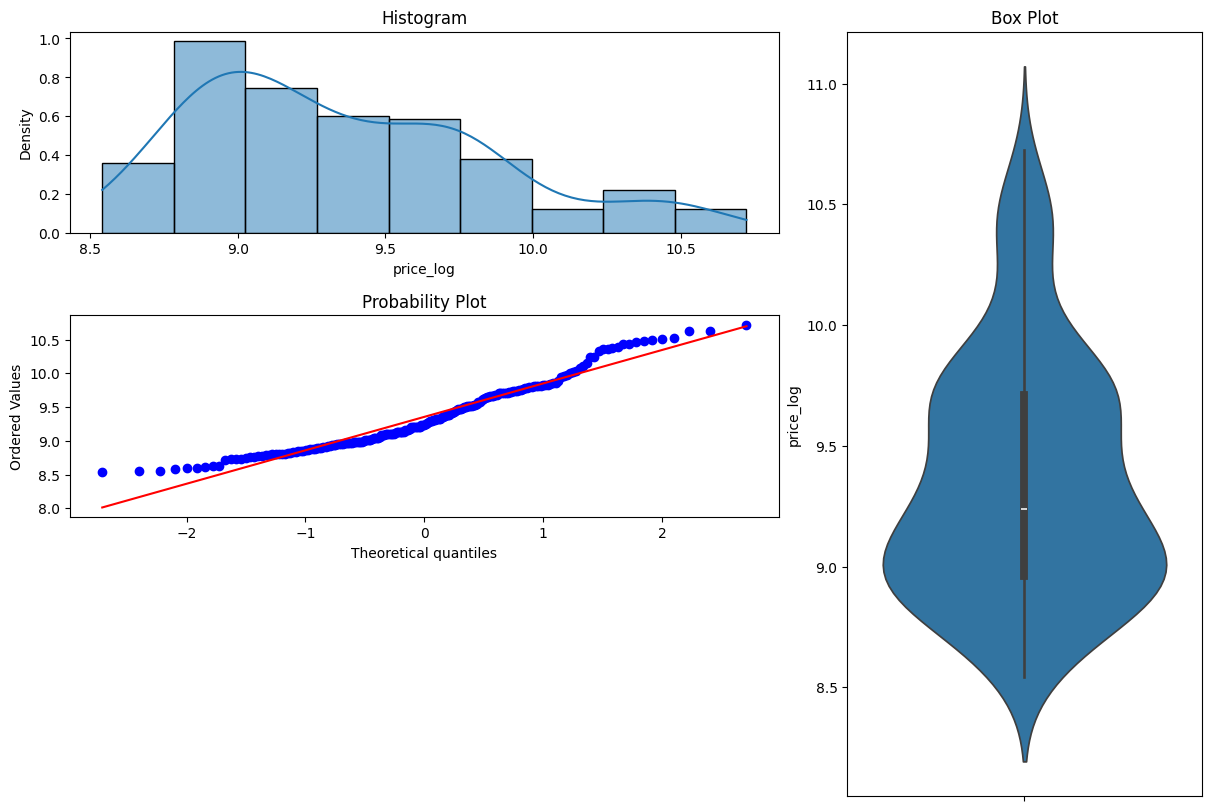

In [32]:
# Apply log transform and re-visualize the target distribution.
data['price_log'] = np.log(data['price'])
plotting_3_chart(data, 'price_log')

Re-run the normality test after the log transform to quantify whether normality improved.

In [33]:
# Post-transform normality check.
normaltest(data.price_log.values)

NormaltestResult(statistic=np.float64(14.10341345775947), pvalue=np.float64(0.0008659297880185564))

The log transform often improves symmetry, even if perfect normality is not achieved.

Other common choices include square-root and Box-Cox transformations. Box-Cox is useful because it learns an optimal power parameter $\lambda$ from the data.

#### 3.3.2. Exercise 4

Apply `boxcox()` to the **original, untransformed** target (`previous_data.price`) and then run `normaltest()` on the transformed result.

Interpretation prompt: compare this p-value with the log-transform p-value and explain which transform appears more effective for this dataset.

In [34]:
# Use the original target snapshot (before log transform).
cp_result = boxcox(previous_data.price)
boxcox_price = cp_result[0]

# Statistical normality check after Box-Cox transform.
normaltest(boxcox_price)

NormaltestResult(statistic=np.float64(16.727141852202635), pvalue=np.float64(0.00023321006918393852))

**Interpretation:**

- Higher p-values (relative to pre-transform) suggest movement toward normality.
- p-value still <= 0.05 means noticeable non-normality remains.

In practice, transformation can still be useful even when normality is not perfect, because it may stabilize variance and improve model behavior.

#### 3.3.3. Sanity Check: Compare Transformation Diagnostics

Use this quick diagnostic block to compare original, log, and Box-Cox transformed targets side by side.

What this prints:

- Sample size used in each test (to confirm apples-to-apples comparison)
- D'Agostino normality-test p-values
- Skewness values (shape asymmetry): positive means right-skewed, negative means left-skewed, and values closer to 0 indicate more symmetry.
- Estimated Box-Cox $\lambda$ parameter

Interpretation reminder: a higher normality-test p-value can indicate movement toward normality, but this metric should be interpreted together with Q-Q plots and downstream model performance.

In [35]:
from scipy.stats import skew, boxcox
from scipy.stats.mstats import normaltest

# Build comparable arrays from the same original target snapshot.
y_original = previous_data['price'].values
y_log = np.log(previous_data['price'].values)
y_boxcox, boxcox_lambda = boxcox(previous_data['price'].values)

# Normality-test p-values (D'Agostino and Pearson test).
p_original = normaltest(y_original).pvalue
p_log = normaltest(y_log).pvalue
p_boxcox = normaltest(y_boxcox).pvalue

# Compact comparison table.
comparison = pd.DataFrame({
    'version': ['original', 'log', 'boxcox'],
    'n_samples': [len(y_original), len(y_log), len(y_boxcox)],
    'normaltest_pvalue': [p_original, p_log, p_boxcox],
    'skewness': [skew(y_original), skew(y_log), skew(y_boxcox)]
})

print(f"Estimated Box-Cox lambda: {boxcox_lambda:.6f}")
comparison

Estimated Box-Cox lambda: -0.628081


,version,n_samples,normaltest_pvalue,skewness
0,original,205,1.578345e-17,1.764644
1,log,205,8.659298e-04,0.667955
2,boxcox,205,2.332101e-04,0.093464


> Important note for THIS dataset: Box-Cox may produce much lower skewness than log-transform, which means stronger symmetry improvement even if the normality-test p-value is not the highest.

### 3.4. Multicollinearity

Multicollinearity occurs when predictors carry overlapping information. This can inflate variance of coefficient estimates and make interpretation unstable.

Common consequences:
- Coefficients become sensitive to small data changes.
- Signs/magnitudes may look counterintuitive.
- Inference on individual predictors becomes less reliable.

A correlation heatmap is a quick screening tool; in later modules, regularization methods (Ridge/Lasso) are standard remedies.

#### 3.4.1. Exercise 5

Use a heatmap to inspect numeric-feature correlations.

Interpretation prompt: identify at least one highly correlated predictor pair and discuss why that may challenge coefficient-level interpretation.

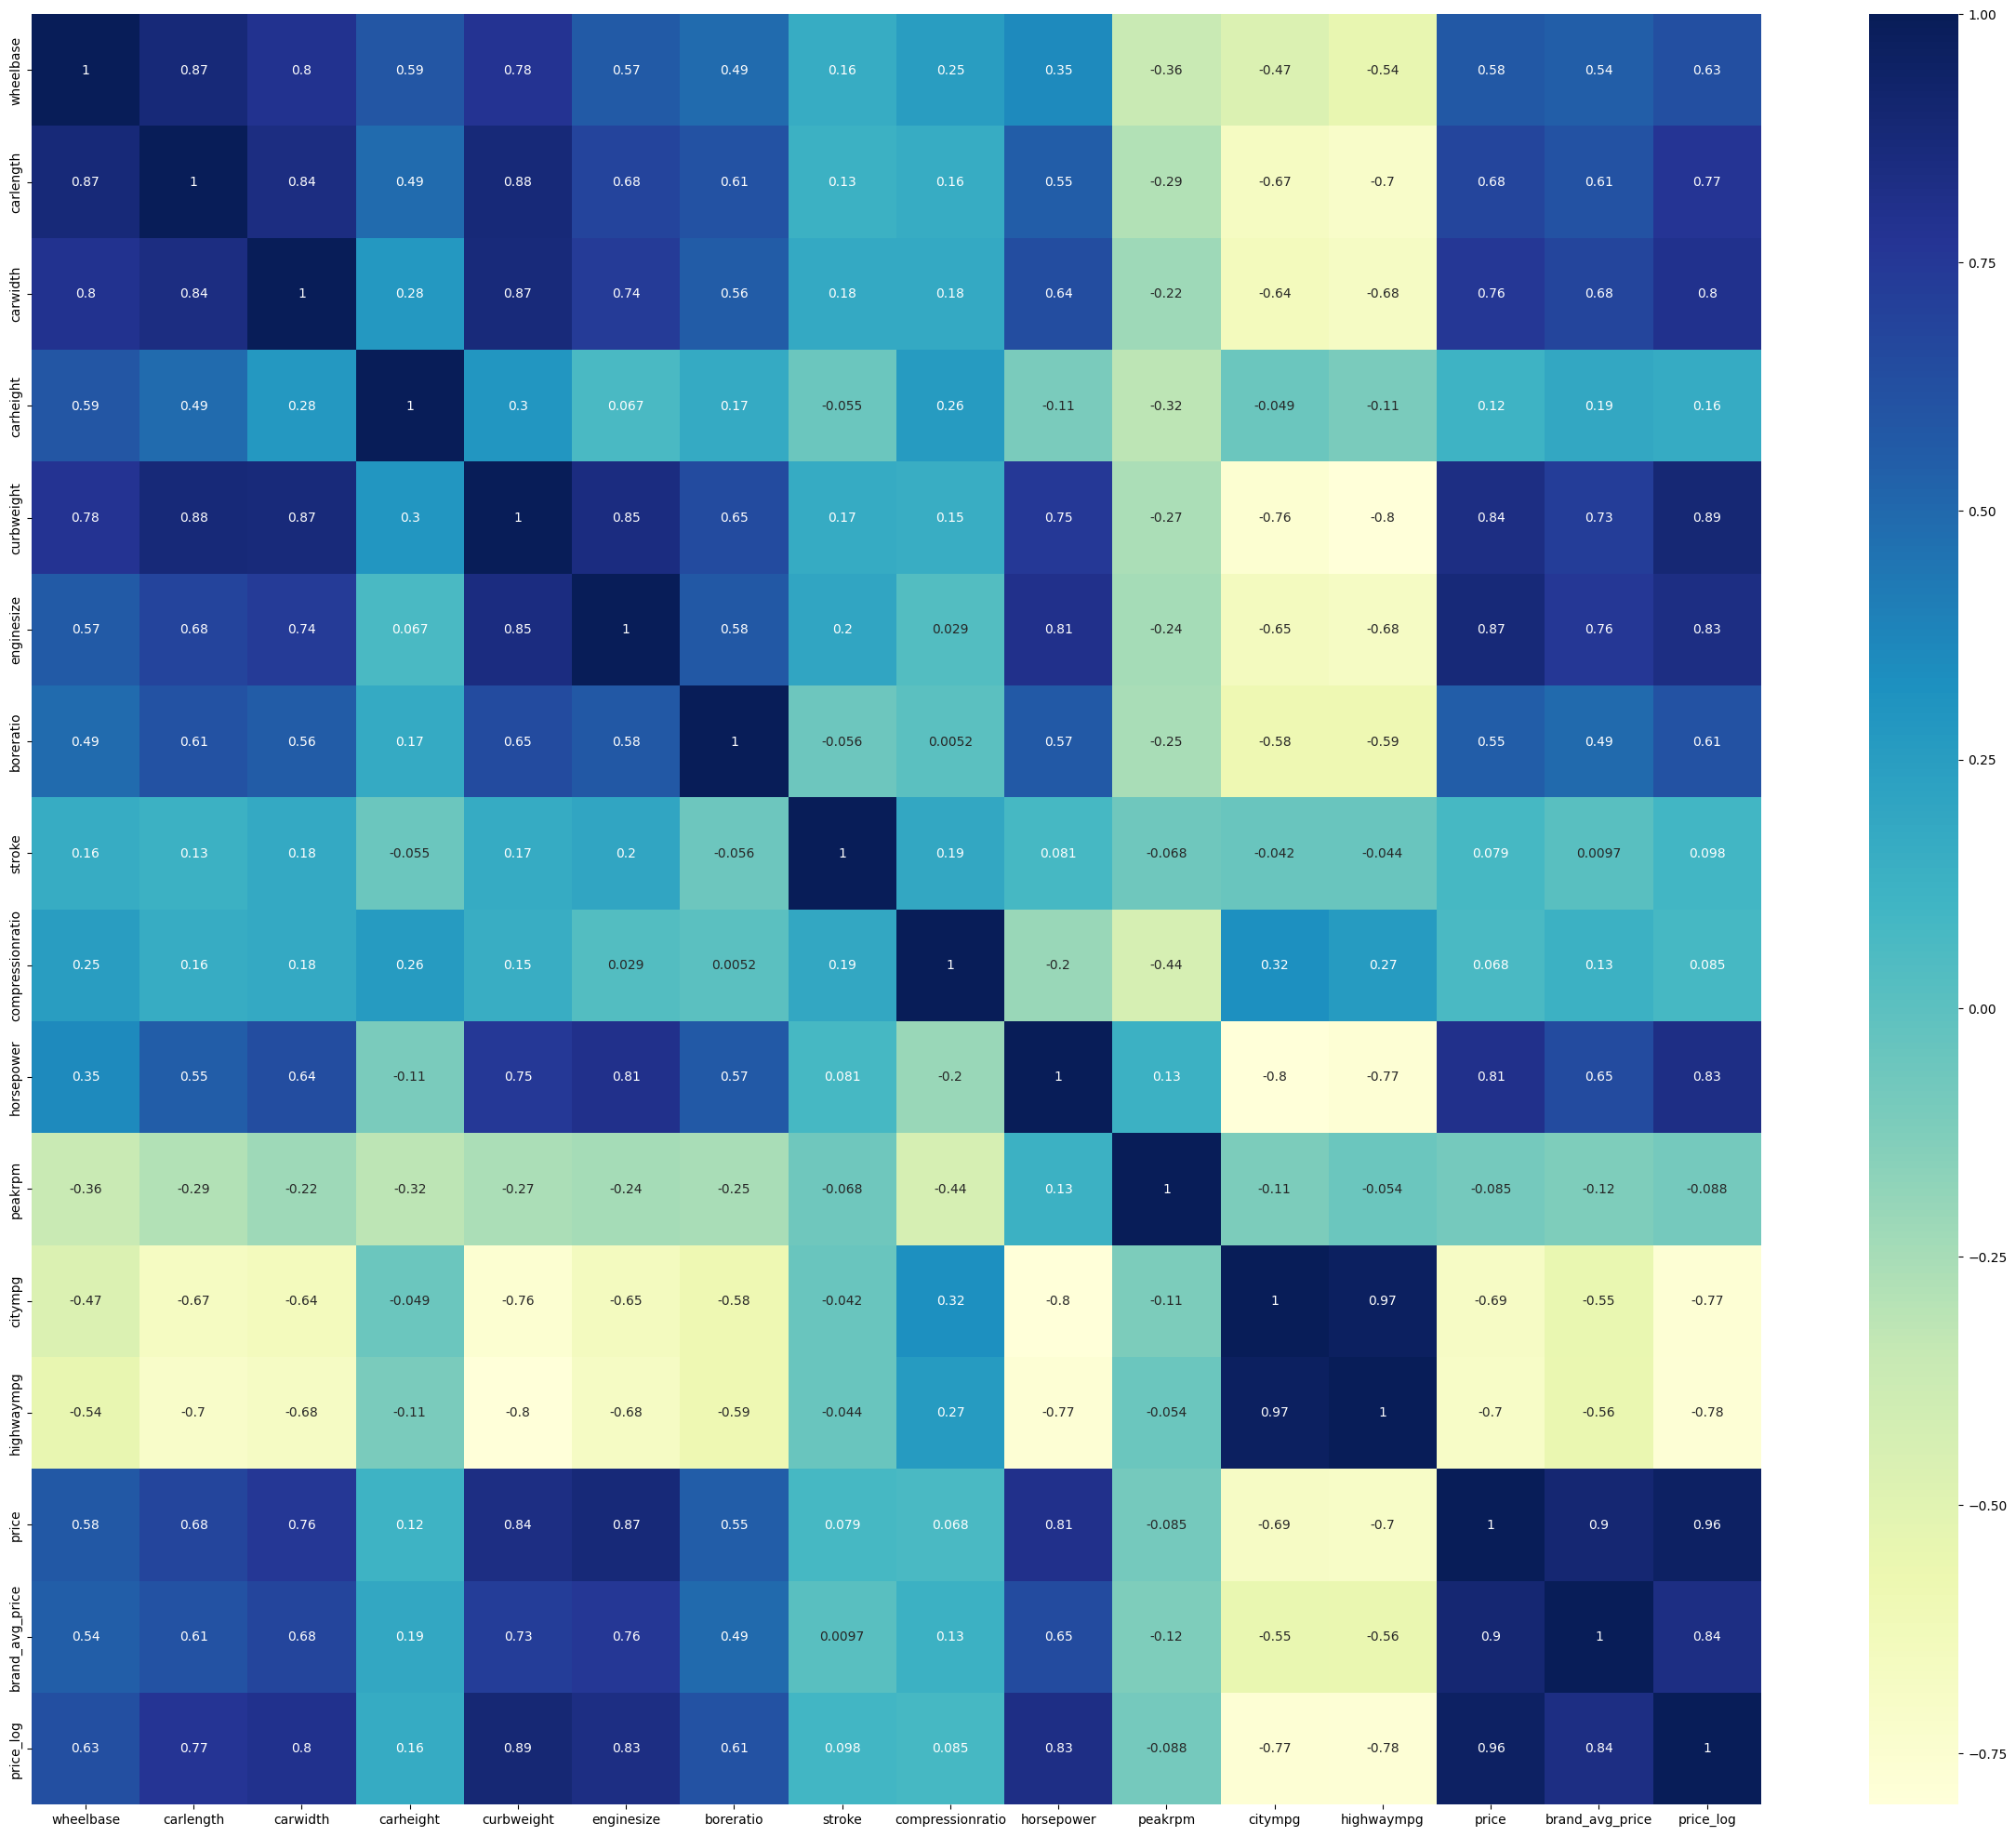

In [36]:
# Enter your code and run the cell
num = data.select_dtypes(include = ['int64', 'float64'])
plt.figure(figsize = (30, 25))
sns.heatmap(num.corr(), annot = True, cmap="YlGnBu")
plt.show()

Observation: several predictors are strongly correlated, so multicollinearity is present.

This does not always harm prediction dramatically, but it does reduce coefficient interpretability and can increase estimate variance.


## 4. Linear Regression Modeling Workflow

This section follows an industry-style supervised-learning pattern:

- Define modeling columns and target
- Split train/test first
- Fit preprocessing on training data only
- Train model and evaluate on unseen test data

This order reduces leakage risk and improves reliability of performance estimates.

### 4.1. Data Selection

Let's create a modeling DataFrame containing only selected predictors and the target.

Why: explicit column selection improves reproducibility and prevents accidental feature leakage from irrelevant fields.

In [37]:
selected_columns=['price', 'fueltype', 'aspiration','carbody', 'drivewheel','wheelbase', 'brand_category', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'boreratio','horsepower', 'carlength','carwidth','citympg','highwaympg']

# Keep original target scale here; target transforms (if any) will be handled in the model wrapper.
selected_df = previous_data[selected_columns].copy()
selected_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           205 non-null    float64
 1   fueltype        205 non-null    object 
 2   aspiration      205 non-null    object 
 3   carbody         205 non-null    object 
 4   drivewheel      205 non-null    object 
 5   wheelbase       205 non-null    float64
 6   brand_category  205 non-null    object 
 7   curbweight      205 non-null    int64  
 8   enginetype      205 non-null    object 
 9   cylindernumber  205 non-null    object 
 10  enginesize      205 non-null    int64  
 11  boreratio       205 non-null    float64
 12  horsepower      205 non-null    int64  
 13  carlength       205 non-null    float64
 14  carwidth        205 non-null    float64
 15  citympg         205 non-null    int64  
 16  highwaympg      205 non-null    int64  
dtypes: float64(5), int64(5), object(7)


* **Identify categorical columns**

> Note: Always avoid hard-coding the column names; this keeps the workflow robust if schema changes.

In [38]:
categorical_columns = [col for col, dtype in selected_df.dtypes.items() if dtype == 'O']
categorical_columns

['fueltype',
 'aspiration',
 'carbody',
 'drivewheel',
 'brand_category',
 'enginetype',
 'cylindernumber']

* **Derive `numeric_columns` from the selected schema**

In [39]:
numeric_columns = [
    col for col in selected_df.columns
    if col not in categorical_columns + ['price']
]
numeric_columns

['wheelbase',
 'curbweight',
 'enginesize',
 'boreratio',
 'horsepower',
 'carlength',
 'carwidth',
 'citympg',
 'highwaympg']

Split into predictors (`X`) and target (`y`).

This explicit separation keeps the supervised-learning interface clear and prevents accidental target leakage into features.

In [40]:
target_column = 'price'
X = selected_df.drop(target_column, axis=1)
X.head()

,fueltype,aspiration,carbody,drivewheel,wheelbase,brand_category,curbweight,enginetype,cylindernumber,enginesize,boreratio,horsepower,carlength,carwidth,citympg,highwaympg
0,gas,std,convertible,rwd,88.6,Mid_Range,2548,dohc,four,130,3.47,111,168.8,64.1,21,27
1,gas,std,convertible,rwd,88.6,Mid_Range,2548,dohc,four,130,3.47,111,168.8,64.1,21,27
2,gas,std,hatchback,rwd,94.5,Mid_Range,2823,ohcv,six,152,2.68,154,171.2,65.5,19,26
3,gas,std,sedan,fwd,99.8,Mid_Range,2337,ohc,four,109,3.19,102,176.6,66.2,24,30
4,gas,std,sedan,4wd,99.4,Mid_Range,2824,ohc,five,136,3.19,115,176.6,66.4,18,22


In [41]:
y = selected_df[target_column].copy()
y.head()

0    13495.0
1    16500.0
2    16500.0
3    13950.0
4    17450.0
Name: price, dtype: float64

*The length of the feature matrix (X) and target vector (y) should be the same.*

In [ ]:
len(X), len(y)

(205, 205)

Inspect category frequencies before encoding.

Rare categories (levels) are operationally important because train/test splits can omit them in one partition, which can affect encoding behavior and model stability. Such rare levels can create unstable estimates and need careful handling (for example, `handle_unknown='ignore'` in one-hot encoding).

In [43]:
for col in categorical_columns:
    print(f'Column: {col}')
    print(X[col].value_counts(dropna=False))
    print('-' * 40)

Column: fueltype
fueltype
gas       185
diesel     20
Name: count, dtype: int64
----------------------------------------
Column: aspiration
aspiration
std      168
turbo     37
Name: count, dtype: int64
----------------------------------------
Column: carbody
carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64
----------------------------------------
Column: drivewheel
drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64
----------------------------------------
Column: brand_category
brand_category
Budget       95
Mid_Range    86
Luxury       24
Name: count, dtype: int64
----------------------------------------
Column: enginetype
enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64
----------------------------------------
Column: cylindernumber
cylindernumber
four      159
six        24
five       11
eight       5
two       

Now we have completed the core setup under **4.1 Data Selection**:

- We selected only the columns needed for modeling (`selected_df`).
- We separated predictors (`X`) from target (`y`).
- We identified categorical vs numeric columns dynamically.
- We inspected category frequencies to spot rare levels.

These steps make the next preprocessing stage safer and clearer. Next, we define a preprocessing pipeline that will encode categorical features and scale numeric features in a consistent, reproducible way.

### 4.2. Preprocessing Strategy (Categorical + Numeric): One-Hot Encoding with ColumnTransformer

We use `ColumnTransformer` so categorical and numeric features are processed in a single reproducible object. This keeps preprocessing explicit, modular, and production-friendly.

- Categorical: `OneHotEncoder(handle_unknown='ignore')`
- Numeric: `StandardScaler()`

We encode categorical predictors into numeric indicator columns so linear regression can consume the data.

Let's build an encoding workflow using the following modules.

In [44]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor

In the next cell, we are defining a `preprocessor` object using `ColumnTransformer` that applies different transforms by column type.

- categorical columns are one-hot encoded with `OneHotEncoder(handle_unknown='ignore')`
- numeric columns are standardized with `StandardScaler()`
- all other columns are dropped via `remainder='drop'`

This gives a clean preprocessing contract for modeling and production reuse.

> What does `handle_unknown='ignore'` do?

 > During prediction, if a category appears that was not present in training, the encoder will not crash. That unseen category is ignored and encoded as zeros for that feature’s one-hot columns. This makes inference more robust when real-world data contains new categorical levels.

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ('num', StandardScaler(), numeric_columns),
    ],
    remainder='drop'
 )
preprocessor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


The core preprocessing object is now ready. Next, we move into train-test split and model training.

## 5. Train-Test Split

Split data before fitting any preprocessing or model objects.

This is one of the most important safeguards against data leakage.

We use a 70/30 split (`test_size=0.30`) and a fixed `random_state` for reproducibility.

Given the length of our dataset `len(X)` and `len(y)` is `dataset_len`,
- the length of `X_train` should be round(dataset_len*7/10), and 
- the length of `X_test` should be round(dataset_len*3/10).

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=0
)
X_train.shape, X_test.shape

((143, 16), (62, 16))

In [ ]:
dataset_len = len(X)
#Check the length of the X_test set.
round(dataset_len*3/10)

62

## 6. Build End-to-End Pipeline

Instead of scaling/encoding manually, we package preprocessing + model into one pipeline. This improves reproducibility and prevents train/test inconsistencies.

We also wrap `LinearRegression` with `TransformedTargetRegressor` (`log1p`/`expm1`) so target transformation is handled inside the estimator.

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [50]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])
model

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Fit the full pipeline on training data only.

What `model.fit(X_train, y_train)` learns in this workflow:
- the one-hot encoder learns which categories exist in each categorical feature (from `X_train`)
- the scaler learns numeric scaling statistics (mean and standard deviation from `X_train`)
- the linear regressor learns feature weights and an intercept that best map processed features to the target (on transformed `y_train` inside `TransformedTargetRegressor`)

In short, the model learns both **how to preprocess** and **how to predict** from training data only.

### Bridge From Previous Guide: Same Logic, Cleaner Packaging

In the previous guide, we did the target transformation with a manual workflow (transform `y_train`, fit, predict in transformed space, then inverse-transform). The core idea is exactly the same here as well.

Connecting the two approaches:
- Previous guide (manual): We explicitly transformed `y_train` (for example, Box-Cox), fit the model on transformed target, and then handled inverse interpretation manually.
- This guide (wrapped): `TransformedTargetRegressor` performs target transform during `fit` and inverse transform during `predict` automatically.

- This automation reduces bookkeeping errors and keeps preprocessing + modeling in one reproducible pipeline.
- It makes train/test workflow cleaner and easier to maintain in production.
- Predictions remain in the original price scale, so evaluation metrics are directly interpretable.

Note: The previous guide also included polynomial feature expansion and Box-Cox. Here, we keep the main path simpler (`log1p`/`expm1`) to focus on leakage-safe pipeline structure.

#### Quick Map: Similarities and Differences

**Similarities Across Both Guides**

| aspect | previous guide | this guide |
|---|---|---|
| train/test discipline | `X_train, X_test, y_train, y_test = train_test_split(...)` | `X_train, X_test, y_train, y_test = train_test_split(...)` |
| scaling numeric features | `s = StandardScaler()` then `X_train_s = s.fit_transform(X_train)` | `('num', StandardScaler(), numeric_columns)` inside `ColumnTransformer(...)` |
| target transformation goal | `bc_result2 = boxcox(y_train)` then `y_train_bc = bc_result2[0]` | `TransformedTargetRegressor(regressor=LinearRegression(), func=np.log1p, inverse_func=np.expm1)` |
| evaluation mindset | `y_pred_bc = lr.predict(X_test_s)` followed by test-set evaluation | `y_pred = model.predict(X_test)` followed by `mean_squared_error`, `mean_absolute_error`, and `r2_score` |

**Key Differences Between the Guides**

| aspect | previous guide | this guide |
|---|---|---|
| target transform implementation | `bc_result2 = boxcox(y_train)` and `y_train_bc = bc_result2[0]` are written explicitly before `lr.fit(...)` | target transform is wrapped inside `TransformedTargetRegressor(...)` and triggered automatically by `model.fit(X_train, y_train)` |
| preprocessing architecture | preprocessing steps are separate: `pf.fit_transform(X)`, `s.fit_transform(X_train)`, `s.transform(X_test)` | preprocessing is unified: `Pipeline([('preprocessor', preprocessor), ('regressor', ...)])` |
| prediction output scale | model predicts in transformed space with `y_pred_bc = lr.predict(X_test_s)`, so inverse interpretation must be handled explicitly | `y_pred = model.predict(X_test)` already returns predictions on the original price scale because inverse transform is automatic |
| feature engineering emphasis | includes polynomial expansion with `pf = PolynomialFeatures(degree=2, include_bias=False)` and `X_pf = pf.fit_transform(X)` | main path intentionally skips polynomial expansion to focus on leakage-safe pipeline design and reproducibility |

In [51]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 6.1. Optional Introspection: What the Fitted Preprocessor Created

We have already fit the pipeline. Before moving to prediction, this optional check helps you connect the previous `.fit(...)` step to a concrete result: the transformed feature space used by the model.

What the next code cell will show:
- total number of transformed features after encoding/scaling
- a preview of transformed feature names (for example, expanded one-hot columns)

This is optional and mainly for interpretability and debugging, not required for pipeline execution.

In [70]:
# Access the fitted preprocessor learned during model.fit(...).
fitted_preprocessor = model.named_steps['preprocessor']

# Feature names created after one-hot encoding + numeric scaling pipeline.
feature_names = fitted_preprocessor.get_feature_names_out()

# Strip transformer prefixes (e.g., 'cat__', 'num__') for easier reading.
clean_feature_names = [name.split('__', 1)[-1] for name in feature_names]

summary = pd.Series({
    'input_features_before_transform': X_train.shape[1],
    'transformed_features_after_preprocessor': len(feature_names)
})
summary

# Preview first transformed feature names used by the regressor.
clean_feature_names[:20]

['fueltype_diesel',
 'fueltype_gas',
 'aspiration_std',
 'aspiration_turbo',
 'carbody_convertible',
 'carbody_hardtop',
 'carbody_hatchback',
 'carbody_sedan',
 'carbody_wagon',
 'drivewheel_4wd',
 'drivewheel_fwd',
 'drivewheel_rwd',
 'brand_category_Budget',
 'brand_category_Luxury',
 'brand_category_Mid_Range',
 'enginetype_dohc',
 'enginetype_l',
 'enginetype_ohc',
 'enginetype_ohcf',
 'enginetype_ohcv']

## 7. Generate Predictions

Because preprocessing and target transform are inside `model`, one call to `predict(X_test)` is enough.

In [73]:
y_pred = model.predict(X_test)

### 7.1. Visual Check: Predicted vs True Values

Before metric calculation, this plot gives a quick visual check of calibration.

- x-axis: true prices (`y_test`)
- y-axis: predicted prices (`y_pred`)
- dashed diagonal: perfect predictions (where predicted equals true)

If points cluster near the diagonal, predictions are generally accurate; systematic shifts above/below the line suggest bias.

> Important reminder: although the model learned on a transformed version of the target internally, `y_pred` returned by `model.predict(X_test)` has already been inverse-transformed back to the original price scale. That is why `y_pred` can be compared directly with `y_test` here.

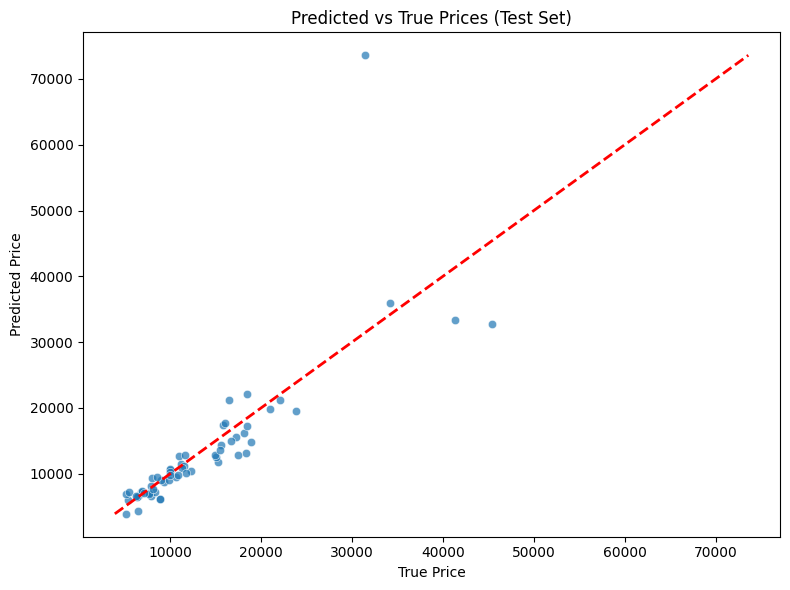

In [72]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)

# Reference line for perfect predictions: y_pred = y_true
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.title('Predicted vs True Prices (Test Set)')
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.show()

## 8. Model Evaluation

Evaluate with complementary metrics: MSE, RMSE, MAE, and $R^2$.

Reminder of what we learned and applied:
- We used a **target transformation** during training via `TransformedTargetRegressor` with `log1p`/`expm1`.
- Rationale: car prices are right-skewed, so transforming the target can stabilize variance and improve linear fit behavior.

> Important: predictions are automatically inverse-transformed back to the **original price scale**, so the metrics below are interpretable in real price units.

Before computing the metrics, first clarify what each one measures:

- **MSE** (Mean Squared Error): the average of squared prediction errors. Larger mistakes are penalized more heavily because the errors are squared.
- **RMSE** (Root Mean Squared Error): the square root of MSE, which brings the error back to the original target units.
- **MAE** (Mean Absolute Error): the average absolute prediction error, also in the original target units.
- **$R^2$** (coefficient of determination): how much better the model predicts compared with a simple baseline that always predicts the mean target value.

The comparison logic is important:

- For MSE, RMSE, and MAE, "lower" does **not** mean much by itself. It means lower **than another model, a baseline, or a previous version of the workflow on the same prediction task and test set**.
- For $R^2$, "higher" is better. $R^2$ = 1 means perfect prediction, $R^2$ = 0 means the model is no better than predicting the mean of the target, and $R^2$ < 0 means the model is worse than that baseline. The practical range of $R^2$ is $[-\infty, 1]$, contrary to a common misconception of [-1, 1].

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

pd.Series({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

MSE     3.586125e+07
RMSE    5.988426e+03
MAE     2.394110e+03
R2      4.569552e-01
dtype: float64

## 9. Interpreting Metrics

Use metrics together, not in isolation. The main goal is not to memorize one "best" metric, but to understand what kind of prediction error each metric emphasizes and what baseline it is being compared against.

- MAE: often the easiest to explain because it tells you the average prediction miss in original price units.
- RMSE: also in original price units, but it penalizes larger errors more strongly than MAE.
- MSE: useful mathematically for optimization, but less intuitive to interpret directly because it is in squared units.
- $R^2$: summarizes performance relative to the mean-target baseline, so it is most useful for understanding how much explanatory power the model adds beyond that simple reference point.

### 9.1. Residual Snapshot

A quick residual check helps detect systematic under/ over-prediction patterns.

Compute residuals as `y_true - y_pred`.

In [56]:
residuals = y_test - y_pred
residuals.describe()

count       62.000000
mean       169.541025
std       6034.892193
min     -42202.610206
25%       -421.480644
50%        469.923921
75%       1667.004316
max      12586.789554
Name: price, dtype: float64

How to interpret `residuals.describe()` in this workflow:

- `count`: number of residuals, which should match the number of test rows.
- `mean`: average residual. A value close to 0 suggests little overall bias.
- `std`: typical spread of residuals around the mean; smaller values indicate tighter errors.
- `min` and `max`: most extreme under-prediction and over-prediction values.
- `25%`, `50%`, `75%`: quartiles. The `50%` value is the median residual and is useful for checking whether errors are centered near 0.

Practical reading tip: if the center (`mean` and `50%`) is near 0 and the spread is not dominated by very large extremes, the model errors are generally more balanced.

### 9.2. Visualize residual distribution (Optional)
This often gives a quick sanity check.

In [57]:
import seaborn as sns

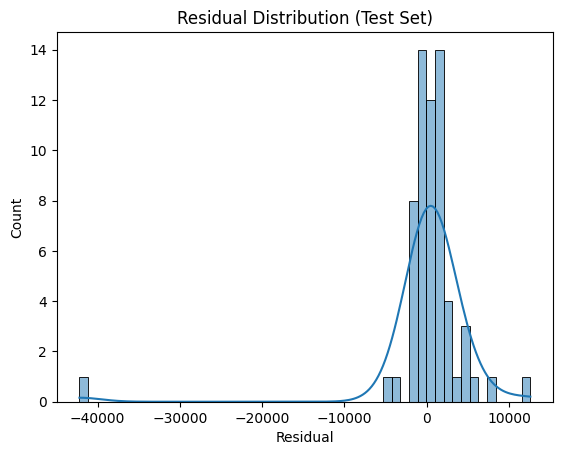

In [74]:
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution (Test Set)')
plt.xlabel('Residual')
plt.show()

If residuals are strongly asymmetric or patterned, revisit features, transformations, and model choice.

## 10. Guide Wrap-Up: What We Learned Here

This guide focused on the **core supervised-regression workflow** that should become your default foundation before moving to more advanced modeling.

By completing this notebook, you practiced how to:

- clean and structure tabular data for modeling
- separate train/test before fitting transforms to prevent leakage
- preprocess mixed data types with `ColumnTransformer`
- build one end-to-end `Pipeline` for reproducibility
- handle a skewed target with `TransformedTargetRegressor`
- evaluate predictions with MSE, RMSE, MAE, and $R^2$
- inspect residual behavior to diagnose model fit

This is already a strong baseline for responsible linear-regression practice.

## 11. What We Will Learn Next for Production-Grade Regression

To keep cognitive load manageable, I intentionally stop this guide at the foundational workflow. In later guides, we will add methods that improve generalization, robustness, and deployment readiness.

Next topics include:

- **Polynomial regression / feature expansion**: to model nonlinear relationships while still using linear-model machinery.
- **Cross-validation**: to estimate performance stability beyond one train/test split.
- **Regularization with Ridge, Lasso, and Elastic Net**: to control overfitting, improve coefficient stability, and support feature selection.
- **Model comparison and selection workflow**: to decide when a more complex model is truly better than the baseline.

Learning strategy reminder: master the workflow in this notebook first, then layer these advanced tools one by one. I hope this sequence reduces overload and leads to stronger long-term intuition.